# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime

from torchvision.io import read_image


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [2]:
torch.__version__

'2.6.0+cu126'

In [3]:
torch.cuda.is_available()

True

## Loading labels

In [4]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png
...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png


### DataLoader

In [5]:
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.img_labels = data
        self.img_labels['fullpath'] = DATA_PATH+"DRR_images/"+self.img_labels['DRR filename']+".png"
        self.img_dir = DATA_PATH+"DRR_images"
        self.transform = None
        self.target_transform = None
    
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        image = plt.imread(self.img_labels.iloc[idx]["fullpath"])
        label = self.img_labels.iloc[idx]["score"]
        return image, label
    
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(CustomImageDataset(train), batch_size=32, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(CustomImageDataset(val), batch_size=32, shuffle=True)


Feature batch shape: torch.Size([32, 256, 256])
Labels batch shape: torch.Size([32])


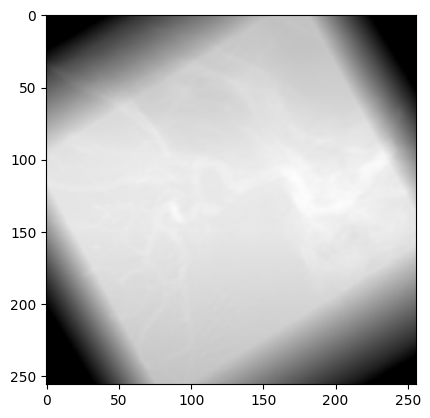

Label: 6.179545454545455


In [6]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [7]:
import torch.nn.functional as F
class Block(nn.Module):
    def __init__(self):
        super(Block, self).__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(256*256, 1)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)

        return x


In [8]:
device = torch.device("cuda")
model = Block().to(device)

summary(model, (1,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 65536]               0
            Linear-2                    [-1, 1]          65,537
Total params: 65,537
Trainable params: 65,537
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.25
Forward/backward pass size (MB): 0.50
Params size (MB): 0.25
Estimated Total Size (MB): 1.00
----------------------------------------------------------------


In [9]:
#output = model(torch.randn(32,1,256,256))

### Loss function

In [14]:
loss_fn = nn.MSELoss()
loss_fn.to(device=device)

MSELoss()

### Optimizer

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


### Training

In [19]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device).float())
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            #tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

In [21]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device).float())
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # Log the running loss averaged per batch
    # for both training and validation
    #writer.add_scalars('Training vs. Validation Loss',
    #                { 'Training' : avg_loss, 'Validation' : avg_vloss },
    #                epoch_number + 1)
    #writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:


c:\Users\const\Documents\GitHub\TeamChallenge_Group6\.venv\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\const\Documents\GitHub\TeamChallenge_Group6\.venv\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\const\Documents\GitHub\TeamChallenge_Group6\.venv\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([14])) that is different to the input size (torch.Size([14, 1])). This will likely l

LOSS train 0.0 valid nan
EPOCH 2:
LOSS train 0.0 valid nan
EPOCH 3:
LOSS train 0.0 valid nan
EPOCH 4:


KeyboardInterrupt: 